# 35 — Internal validity indices: Calinski–Harabasz and Davies–Bouldin

| | |
|---|---|
| **Author** | Blessy Paul |
| **Contributes to** | `xxcluster/measures/validation/internal.py` |
| **Documents** | `documentation/sections/clustering_methods/validity/calinski_harabasz.tex` and `davies_bouldin.tex` |
| **Data** | Iris benchmark dataset |

Evidence that the Calinski–Harabasz and Davies–Bouldin implementations behave as documented by evaluating clustering results on the Iris benchmark dataset and comparing the project implementations with scikit-learn reference scores.

## 1. Setup

Set up the project path and imports so that the project implementations and reference implementations can be evaluated in the same environment.

In [1]:
from pathlib import Path
import sys

sys.path.insert(0, str(Path.cwd().parent))

import numpy as np

from sklearn.cluster import KMeans
from sklearn.metrics import calinski_harabasz_score, davies_bouldin_score

from xxcluster.io.loaders import BenchmarkLoader

## 2. Scope

This notebook verifies the two internal clustering validity indices implemented for Task 35:

- **Calinski–Harabasz Index** — higher scores indicate better-defined clusters.
- **Davies–Bouldin Index** — lower scores indicate better clustering.

The project implementations are evaluated on the Iris benchmark dataset and compared with the corresponding scikit-learn reference metrics.

## 3. Data

Load the Iris benchmark through the project's `BenchmarkLoader`, following the same benchmark-loading approach used by the project notebooks. The Iris dataset contains 150 observations and four numerical features.

In [2]:
dataset = BenchmarkLoader("iris").load()
features = dataset.cluster_matrix()
X = np.asarray(features)

print(f"Iris benchmark: {X.shape[0]} observations, {X.shape[1]} features")

Iris benchmark: 150 observations, 4 features


## 4. Generate cluster labels

Fit K-means to the Iris benchmark to produce cluster labels that can be evaluated by both internal validity indices.

In [3]:
model = KMeans(n_clusters=3, random_state=42, n_init=10)
labels = model.fit_predict(X)

print("Number of clusters:", len(np.unique(labels)))
print("Cluster sizes:", np.bincount(labels))

Number of clusters: 3
Cluster sizes: [62 50 38]


## 5. Calinski–Harabasz Index

Evaluate the K-means clustering using the project's `CalinskiHarabasz` implementation and compare the result with scikit-learn's `calinski_harabasz_score`. The two scores should agree if the project implementation is correct. Higher Calinski–Harabasz scores indicate better-defined clusters.

In [4]:
from xxcluster.measures.validation.internal import CalinskiHarabasz

ch_index = CalinskiHarabasz()

project_ch = ch_index(X, labels)
sklearn_ch = calinski_harabasz_score(X, labels)

print(f"Project Calinski-Harabasz score: {project_ch:.6f}")
print(f"scikit-learn score:             {sklearn_ch:.6f}")
print(f"Difference:                     {abs(project_ch - sklearn_ch):.10f}")

assert np.isclose(project_ch, sklearn_ch)
print("OK: Calinski-Harabasz implementation matches scikit-learn.")

Project Calinski-Harabasz score: 561.627757
scikit-learn score:             561.627757
Difference:                     0.0000000000
OK: Calinski-Harabasz implementation matches scikit-learn.


## 6. Davies–Bouldin Index

Evaluate the same K-means clustering using the project's `DaviesBouldin` implementation and compare the result with scikit-learn's `davies_bouldin_score`. Lower Davies–Bouldin scores indicate better-defined clusters.

In [5]:
from xxcluster.measures.validation.internal import DaviesBouldin

db_index = DaviesBouldin()

project_db = db_index(X, labels)
sklearn_db = davies_bouldin_score(X, labels)

print(f"Project Davies-Bouldin score: {project_db:.6f}")
print(f"scikit-learn score:           {sklearn_db:.6f}")
print(f"Difference:                   {abs(project_db - sklearn_db):.10f}")

assert np.isclose(project_db, sklearn_db)
print("OK: Davies-Bouldin implementation matches scikit-learn.")

Project Davies-Bouldin score: 0.661972
scikit-learn score:           0.661972
Difference:                   0.0000000000
OK: Davies-Bouldin implementation matches scikit-learn.


## 7. Behaviour across different numbers of clusters

Evaluate both internal validity indices across several values of `k`. This demonstrates their documented behaviour rather than verifying only a single clustering result.

For the Calinski–Harabasz Index, higher scores indicate better-defined clusters. For the Davies–Bouldin Index, lower scores indicate better-defined clusters.

In [6]:
results = []

for k in range(2, 11):
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    k_labels = model.fit_predict(X)

    ch_score = CalinskiHarabasz()(X, k_labels)
    db_score = DaviesBouldin()(X, k_labels)

    results.append((k, ch_score, db_score))

print(" k | Calinski-Harabasz | Davies-Bouldin")
print("-" * 43)

for k, ch, db in results:
    print(f"{k:2d} | {ch:17.6f} | {db:15.6f}")

 k | Calinski-Harabasz | Davies-Bouldin
-------------------------------------------
 2 |        513.924546 |        0.404293
 3 |        561.627757 |        0.661972
 4 |        530.765808 |        0.780307
 5 |        495.369906 |        0.815989
 6 |        473.850607 |        0.914158
 7 |        449.536342 |        0.978573
 8 |        438.425530 |        0.951887
 9 |        406.867300 |        1.032386
10 |        392.558373 |        1.017150


## 8. Validation score curves

Plot both internal validity indices across the tested numbers of clusters. The curves illustrate how the Calinski–Harabasz and Davies–Bouldin scores change as the number of clusters increases.

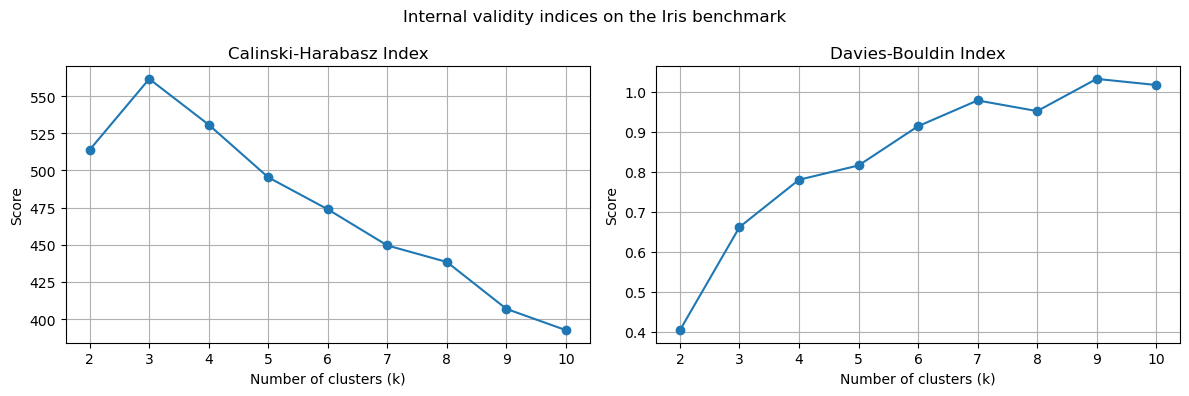

In [7]:
import matplotlib.pyplot as plt

k_values = [r[0] for r in results]
ch_values = [r[1] for r in results]
db_values = [r[2] for r in results]

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].plot(k_values, ch_values, marker="o")
ax[0].set_title("Calinski-Harabasz Index")
ax[0].set_xlabel("Number of clusters (k)")
ax[0].set_ylabel("Score")
ax[0].grid(True)

ax[1].plot(k_values, db_values, marker="o")
ax[1].set_title("Davies-Bouldin Index")
ax[1].set_xlabel("Number of clusters (k)")
ax[1].set_ylabel("Score")
ax[1].grid(True)

fig.suptitle("Internal validity indices on the Iris benchmark")
plt.tight_layout()
plt.show()

## 9. Summary

- The project `CalinskiHarabasz` implementation produced the same score as scikit-learn's reference implementation on the Iris benchmark.
- The project `DaviesBouldin` implementation also produced the same score as scikit-learn's reference implementation.
- Across different numbers of clusters, the Calinski–Harabasz Index demonstrates its higher-is-better behaviour, while the Davies–Bouldin Index demonstrates its lower-is-better behaviour.
- The validation curves provide a visual comparison of both internal clustering validity indices across `k = 2` to `k = 10`.

These results verify the implementations of the Calinski–Harabasz and Davies–Bouldin indices used for Task 35.